## PtyChee Iterative Ptychogrpahy Demo

Running multi-slice LSQML and ePIE ptychography

Author: Zeyu Wang <br>
October 2025

In [1]:
import numpy as np
from PtyChee.preProcessing import realSpace_bin
from PtyChee import run

4D-STEM data and parameters read in, this data uesd a total dose of only ~36 e<sup>-</sup>/Å<sup>2</sup>.

In [2]:
file_read = 'data/'
file = 'MAPbI3_HT200_a13_ss0.3_31_F3sum.npy'
data_4D = np.load(file_read+file)
print(data_4D.shape)

Voltage = 200               #keV, accelerate votage
alpha = 0.013               #rad, semi convergence angle
scan_step = 0.3             #Å,   scan step size

defocus = -60               #Å,   defocus

(800, 800, 38, 38)


Simple preprocessing like cropping, binning and padding

In [3]:
data_4D = data_4D[-400:,-800:-400,:,:]
data_4D, scan_step = realSpace_bin(data_4D, scan_step, bin_factor=2)

real space bin 2 finished in 0.2140183448791504 s


A data of (800×800×38×38) is processed into (200×200×38×38) to simplify the demo

You can use PtyChee.finRotate to calculate the optimized scan rotate angle, <br>
see 'run_ptyChee_01_findRotate_and_iCoM_MAPbI3_F3sum.ipynb'

In [4]:
scan_rotation_angle = -176   #degrees
scan_flip = False            #flip X axis or not

Run multi-slice mix-state LSQML, a pretty fast iterative ptychogrpahy algorithm


multi-slice LSQML
File: MAPbI3_HT200_a13_ss0.3_31_F3sum.npy

################ Experimental Information ################
Voltage: 200 kV
Alpha: 0.013 rad
scan step: 0.6 Å/pixel
defocus: -60 Å
scan rotation angle: -176 degrees
scan flip x: False

#################### Data Information ####################
data shape: (200, 200, 38, 38)
data type: int32
CBED intensity range: 0 – 14
average CBED intensity: 38.188724517822266
BF center_Y: 18.574074074074073
BF center_X: 18.675925925925927
BF threshold: 0.5
Aperture Radius: 5.775335216480246 pixels

################ Calculatied Calibration #################
reciprocal space pixel size: 0.08975319633381454 1/Å/pixel
real space pixel size: 0.2932016969714284 Å/pixel
ptycho move: 2.0463728764109717 pixels

############### Probe Mixstates Parameters ###############
Probe States: 2
Probe Generation Mode: Hermite
Probe Radius: 7.615773105863909 pixels

############# Object Multi-slice Parameters ##############
Object Slices: 6
recovered objFunc sh

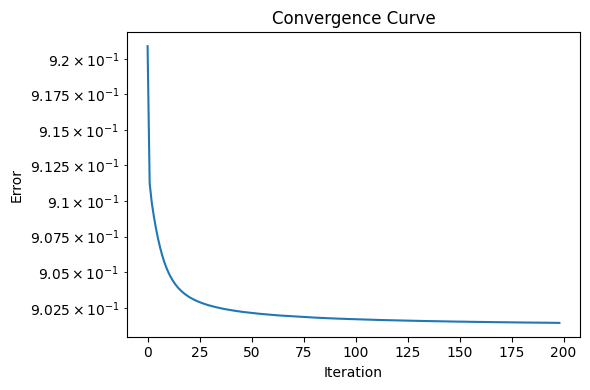

Object saving


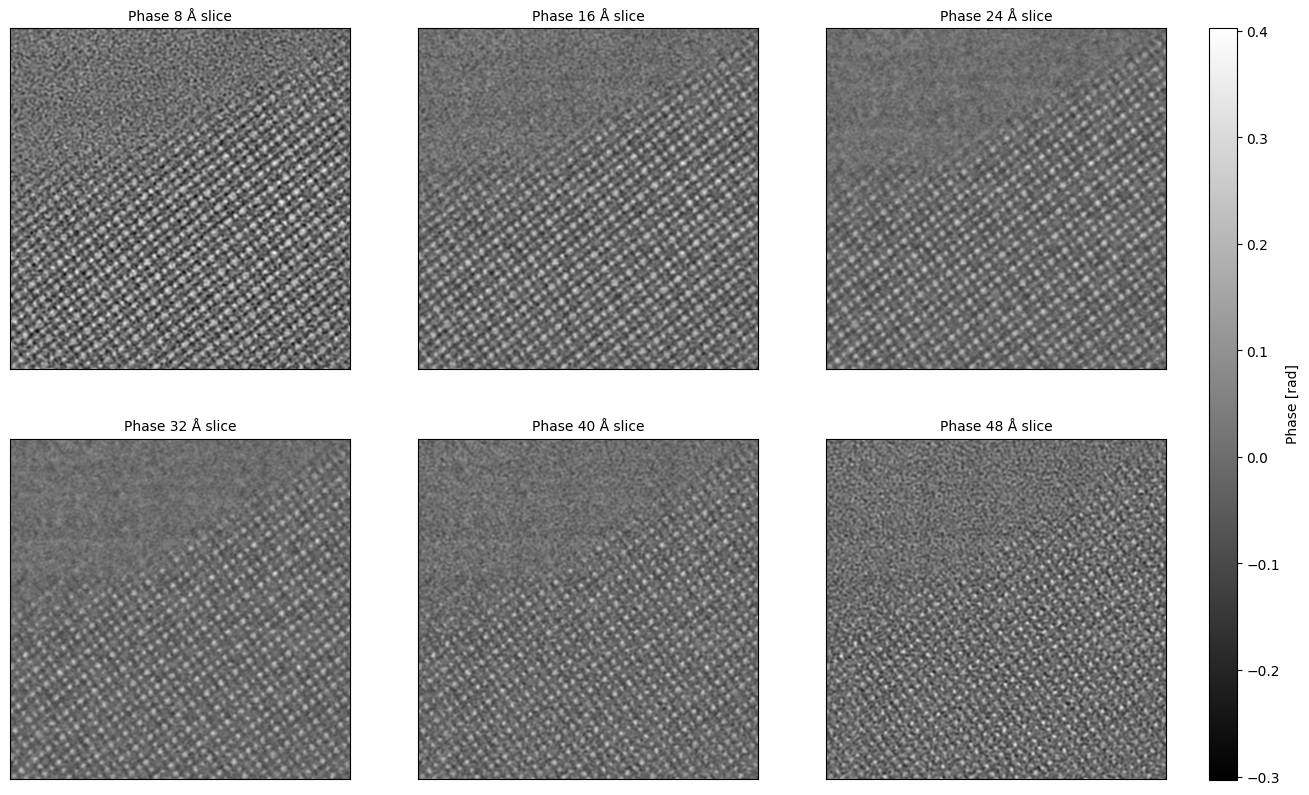

Object Function Summed


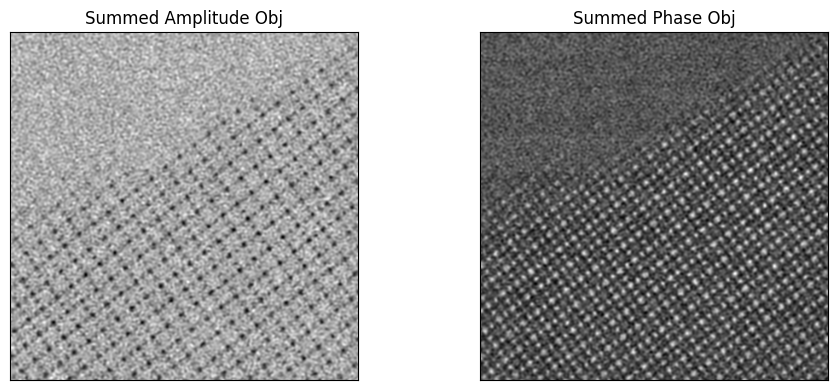

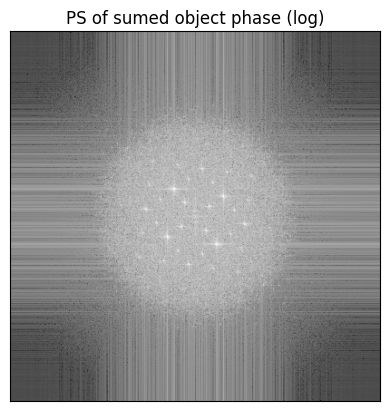

Probe saving


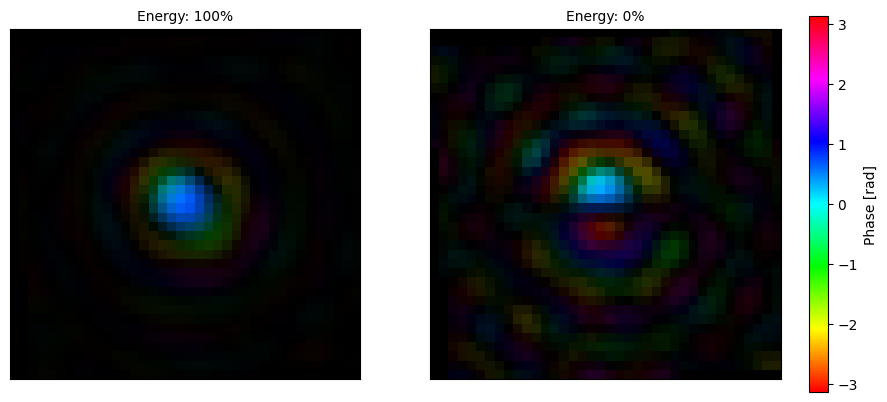

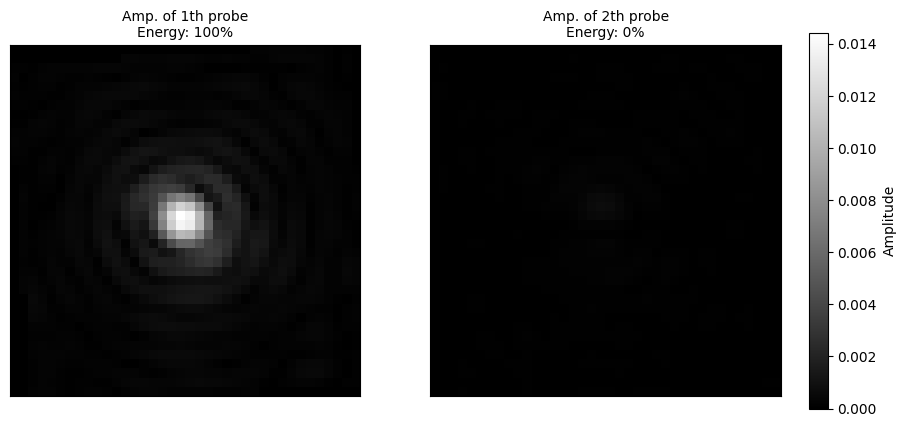

In [5]:
# multi-slice LSQML
run.run_msLSQML(file, data_4D, Voltage, alpha, scan_step, scan_rotation_angle, scan_flip, 
        defocus,
        n_state = 2,                   # probe states number
        n_slice = 6,                   # object slices number
        slice_thickness = 8,          # object slice thickness in Å
        iter_max = 200,                # maximum iteration numner
        s_O = 0.05,                    # step size for updating Object Function
        s_P = 0.05,                    # step size for updating Probe Function
        n_block = 50,                  # block number：The CBEDs are divided into n_block blocks for batch computing, must be divisible by the number of scanning positions
        ks_softThreshold = 0.5,        # soft threshold to constrain the sparsity of the reciprocal space
        save_results = False,
)

Run ePIE, due to the long running time of the ePIE algorithm, only one object slice and one probe state are implemented here


multi-slice ePIE
File: MAPbI3_HT200_a13_ss0.3_31_F3sum.npy

################ Experimental Information ################
Voltage: 200 kV
Alpha: 0.013 rad
scan step: 0.6 Å/pixel
defocus: -60 Å
scan rotation angle: -176 degrees
scan flip x: False

#################### Data Information ####################
data shape: (200, 200, 38, 38)
data type: int32
CBED intensity range: 0 – 14
average CBED intensity: 38.188724517822266
BF center_Y: 18.574074074074073
BF center_X: 18.675925925925927
BF threshold: 0.5
Aperture Radius: 5.775335216480246 pixels

################ Calculatied Calibration #################
reciprocal space pixel size: 0.08975319633381454 1/Å/pixel
real space pixel size: 0.2932016969714284 Å/pixel
ptycho move: 2.0463728764109717 pixels

############### Probe Mixstates Parameters ###############
Probe States: 1
Probe Generation Mode: Hermite
Probe Radius: 7.615773105863909 pixels

############# Object Multi-slice Parameters ##############
Object Slices: 1
recovered objFunc sha

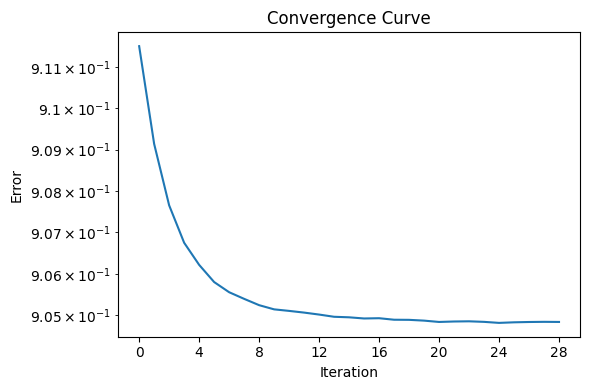

Object saving


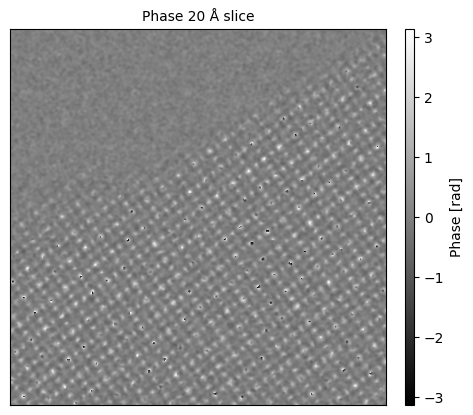

Object Function Summed


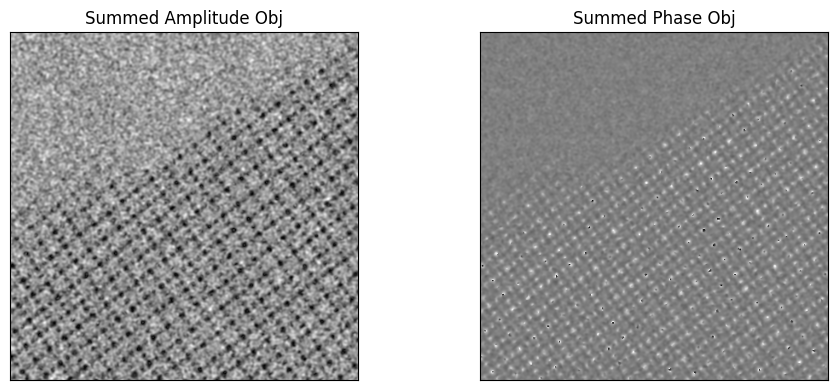

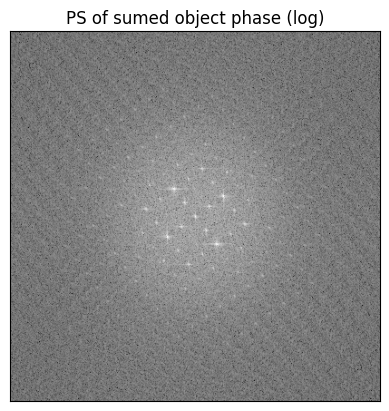

Probe saving


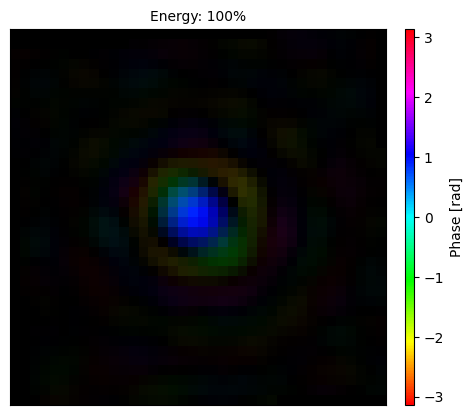

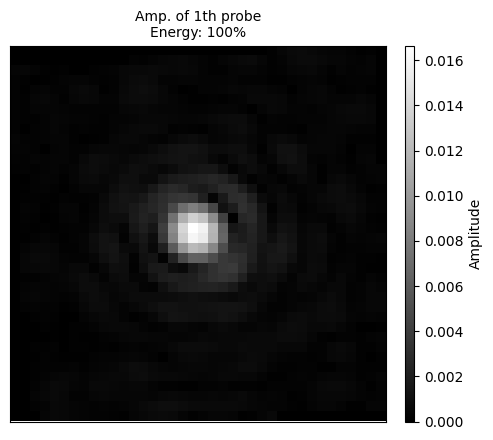

In [6]:
# multi-slice ePIE
run.run_msePIE(file, data_4D, Voltage, alpha, scan_step, scan_rotation_angle, scan_flip, 
        defocus,
        n_state = 1,                   # probe states number
        n_slice = 1,                   # object slices number
        slice_thickness = 20,          # object slice thickness in Å
        iter_max = 30,                 # maximum iteration numner
        s_O = 0.1,                    # step size for updating Object Function
        s_P = 0.01,                    # step size for updating Probe Function
        ks_softThreshold = 0.5,        # soft threshold to constrain the sparsity of the reciprocal space
        save_results = False,
)